In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from pathlib import Path
import numpy as np
import pandas as pd

from aind_hcr_data_loader.codeocean_utils import (
    MouseRecord,
    attach_mouse_record_to_workstation,
    print_attach_results,
)
from aind_hcr_data_loader.hcr_dataset import create_hcr_dataset_from_schema
from aind_hcr_data_loader.pairwise_dataset import create_pairwise_unmixing_dataset

import aind_hcr_qc.viz as viz
from aind_hcr_qc.viz.intergrated_datasets import plot_intensity_violins
from aind_hcr_qc.viz.single_cell_unmixing import (
    plot_spot_projection,
    plot_spot_measure_distributions,
    plot_cell_qc,
    plot_spot_nn_distances,
    plot_adjacent_channel_scatter,
)


import aind_hcr_qc.viz.single_cell_unmixing as scu

from aind_hcr_qc.viz.spot_detection import (
    annotate_spots_df,
    plot_removal_metric_distributions,
)
from aind_hcr_qc.constants import Z1_CHANNEL_CMAP_VIBRANT

In [2]:
# notebook setup
data_dir = Path('/root/capsule/data')
bucket_name = "aind-open-data"

# notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2


In [3]:
# ── configuration ────────────────────────────────────────────────────────────
MOUSE_ID = "755252"
  # use a mouse that has a pairwise_unmixing derived asset
CATALOG_PATH = Path(f"/src/ophys-mfish-dataset-catalog/mice/{MOUSE_ID}.json")
DATA_DIR     = Path("/root/capsule/data")
OUTPUT_DIR = Path(f"/root/capsule/scratch/single_cell_unmixing/{MOUSE_ID}")

# ── attach & load ────────────────────────────────────────────────────────────
record  = MouseRecord.from_json_file(CATALOG_PATH)
results = attach_mouse_record_to_workstation(record)
print_attach_results(results)

dataset = create_hcr_dataset_from_schema(CATALOG_PATH, DATA_DIR)
dataset.summary()

# ── pairwise unmixing (optional) ─────────────────────────────────────────────
# The pairwise asset name lives in derived_assets["pairwise_unmixing"] when present.
pairwise_asset_name = record.derived_assets.get("pairwise_unmixing")

if pairwise_asset_name is not None:
    pairwise_asset_path = DATA_DIR / pairwise_asset_name
    # Some pipeline outputs nest data under a "pairwise_unmixing" subfolder
    if (pairwise_asset_path / "pairwise_unmixing").exists():
        pairwise_asset_path = pairwise_asset_path / "pairwise_unmixing"
    pw_ds = create_pairwise_unmixing_dataset(
        mouse_id=MOUSE_ID,
        pairwise_asset_path=pairwise_asset_path,
        source_dataset=dataset,   # delegates zarr / segmentation calls
        min_dist=1
    )
    pw_ds.summary()
else:
    print("No pairwise_unmixing asset found in catalog record — skipping.")


  [rounds.R1]  HCR_755252_2025-07-02_13-00-00_processed_2025-07-18_09-27-44  →  ✓ attached
  [rounds.R2]  HCR_755252_2025-07-10_13-00-00_processed_2025-07-21_17-35-04  →  ✓ attached
  [rounds.R3]  HCR_755252_2025-07-17_13-00-00_processed_2025-07-21_17-35-16  →  ✓ attached
  [rounds.R4]  HCR_755252_2025-07-24_13-00-00_processed_2025-07-26_19-56-20  →  ✓ attached
  [rounds.R5]  HCR_755252_2025-07-31_13-00-00_processed_2025-08-01_16-55-55  →  ✓ attached
  [derived_assets.roi_shape_metrics]  HCR_755252_2025-07-02_13-00-00_roi-shape-metrics  →  ✓ attached
  [derived_assets.cell_typing]  HCR_755252_cell-typing_2026-03-08_12-00-00  →  ✓ attached
  [derived_assets.pairwise_unmixing]  HCR_755252_pairwise-unmixing_2026-04-20_00-00-01  →  ✓ attached
[DEBUG get_spot_files] key=R1 round_num=1
[DEBUG get_spot_files] folder_path=/root/capsule/data/HCR_755252_2025-07-02_13-00-00_processed_2025-07-18_09-27-44/image_spot_spectral_unmixing exists=False
[DEBUG get_spot_files] unmixed_spots=None  mixed_spo

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2500: UserWarning: [get_spot_files] R4: no unmixed_spots_R4*.pkl found; falling back to R-1 file: unmixed_spots_R-1_minDist_3.pkl
  _warnings.warn(
/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:2509: UserWarning: [get_spot_files] R4: no mixed_spots_R4.pkl found; falling back to R-1 file: mixed_spots_R-1.pkl
  _warnings.warn(


mouse_id: 755252
Could not load metadata for mouse 755252
Cell-typing asset attached: CellTypingFiles(asset='HCR_755252_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓)
HCR Dataset Summary
Mouse ID: 755252
Rounds: R1, R2, R3, R4, R5

Channels by round:
  R1: 488, 514, 594, 405
  R2: 561, 594, 514, 638, 405, 488
  R3: 594, 514, 561, 638, 488, 405
  R4: 488, 514, 638, 561, 405, 594
  R5: 638, 561, 594, 514, 405, 488

Cell-typing: ✓  (CellTypingFiles(asset='HCR_755252_cell-typing_2026-03-08_12-00-00', basic_results=✓, h5ad=✓))

Segmentation files by round:
  R1: resolutions 0, 2, centroids: ✓
  R2: resolutions 0, 2, centroids: ✗
  R3: resolutions 0, 2, centroids: ✗
  R4: resolutions 0, 2, centroids: ✗
  R5: resolutions 0, 2, centroids: ✓

Spot detection files by round:
  R2: channels 594, 514, 561, 638, 488
    594: spots ✓, stats files: 5
    514: spots ✓, stats files: 5
    561: spots ✓, stats files: 5
    638: spots ✓, stats files: 5
    488: spots ✓, stats files: 5
  R3: cha

In [8]:
pw_ds.rounds["R2"].spot_files

SpotFiles(unmixed_cxg=PosixPath('/root/capsule/data/HCR_755252_pairwise-unmixing_2026-04-20_00-00-01/pairwise_unmixing/755252_R2/unmixed_cell_by_gene.csv'), mixed_cxg=PosixPath('/root/capsule/data/HCR_755252_pairwise-unmixing_2026-04-20_00-00-01/pairwise_unmixing/755252_R2/mixed_cell_by_gene.csv'), unmixed_spots=PosixPath('/root/capsule/data/HCR_755252_pairwise-unmixing_2026-04-20_00-00-01/pairwise_unmixing/755252_R2/unmixed_spots_R2_minDist_1.pkl'), mixed_spots=PosixPath('/root/capsule/data/HCR_755252_pairwise-unmixing_2026-04-20_00-00-01/pairwise_unmixing/755252_R2/mixed_spots_R2.pkl'), spot_unmixing_stats=None, ratios_file=PosixPath('/root/capsule/data/HCR_755252_pairwise-unmixing_2026-04-20_00-00-01/pairwise_unmixing/755252_R2/R2_ratios.txt'), unmixed_cxg_filtered=PosixPath('/root/capsule/data/HCR_755252_pairwise-unmixing_2026-04-20_00-00-01/pairwise_unmixing/755252_R2/unmixed_cell_by_gene_filtered.csv'), mixed_cxg_filtered=PosixPath('/root/capsule/data/HCR_755252_pairwise-unmixing

In [9]:

# channel display order and fixed colors
CHAN_ORDER  = ["488", "514", "561", "594", "638"]
CHAN_COLORS = {k: v for k, v in Z1_CHANNEL_CMAP_VIBRANT.items() if k in CHAN_ORDER}

# ── load spots (both tables) for this cell ───────────────────────────────────
mixed_all   = pw_ds.load_all_rounds_spots_mp(table_type="mixed_spots", remove_fg_bg_cols=True)

Loading mixed_spots for round R2: 755252_R2
Loading mixed_spots for round R3: 755252_R3

Loading mixed_spots for round R4: 755252_R4

Loading mixed_spots for round R5: 755252_R5


Number of mixed_spots: 2.943e+07


In [51]:
unmixed_all = pw_ds.load_all_rounds_spots_mp(table_type="unmixed_spots",  remove_fg_bg_cols=False)

Loading unmixed_spots for round R2: 755252_R2
Loading unmixed_spots for round R3: 755252_R3
Loading unmixed_spots for round R4: 755252_R4
Loading unmixed_spots for round R5: 755252_R5




Number of unmixed_spots: 2.306e+07


In [6]:
unmixed_all = pw_ds.load_all_rounds_spots_mp(table_type="unmixed_spots",  remove_fg_bg_cols=True)

Loading unmixed_spots for round R2: 755252_R2

Loading unmixed_spots for round R3: 755252_R3
Loading unmixed_spots for round R4: 755252_R4

Loading unmixed_spots for round R5: 755252_R5


Number of unmixed_spots: 2.306e+07


In [52]:
# ── Annotate once (valid_spot-aware) ──────────────────────────────────────────
mixed_ann, unmixed_ann = scu.annotate_spots_with_valid(mixed_all, unmixed_all)

In [63]:
unmixed_all.columns

Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_514_intensity', 'chan_561_intensity', 'chan_594_intensity',
       'chan_638_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'dist_r', 'dist_to_chan_488',
       'dist_to_chan_514', 'dist_to_chan_561', 'dist_to_chan_594',
       'dist_to_chan_638', 'd_assignment_ratio', 'z_intensity_vs_removed',
       'z_vetoed', 'crosstalk_score', 'unmixed_gene', 'mixed_gene'],
      dtype='object')

# Cluster

In [12]:
labels = pd.read_csv("/root/capsule/data/HCR_755252_pairwise-unmixing_2026-04-20_00-00-01/pairwise_unmixing/inhibitory_cells_unmixed/unmixed_cluster_labels.csv")
cell_ids = pd.read_csv("/root/capsule/data/HCR_755252_pairwise-unmixing_2026-04-20_00-00-01/pairwise_unmixing/inhibitory_cells_unmixed/unmixed_sorted_cell_ids.csv")

In [13]:
# merge labels and cell_ids on index
labels["cell_id"] = cell_ids["cell_id"]
cluster_exemplars = labels.groupby("cluster").sample(n=1, random_state=42)
cluster_exemplars

,Unnamed: 0,cluster,cell_id
131,131,0,43385
167,167,1,71181
373,373,2,17681
622,622,3,46826
853,853,4,61328
1066,1066,5,77674
1134,1134,6,62308
1430,1430,7,29533
1732,1732,8,34972
1739,1739,9,14770


# plot single

In [ ]:
rk = "R2"
cluster = 7


In [60]:
# get round/cell
cluster_cells = labels[labels["cluster"] == cluster]["cell_id"].tolist()

mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]
m_cluster_spots = mx_rnd[mx_rnd["cell_id"].isin(cluster_cells)]
u_cluster_spots = um_rnd[um_rnd["cell_id"].isin(cluster_cells)]

NameError: name 'cluster' is not defined

In [ ]:
mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
u_cell = um_rnd[um_rnd["cell_id"] == cid]

save_kwargs = {"save": True,"output_dir": Path(f"/root/capsule/code/single_cell_unmixing_temp_plots/"),"filename":f"{MOUSE_ID}_{cid}","show": False}
fig = plot_cell_qc(
    m_cell, u_cell, cell_id=cid, round_key=rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    spots_df=u_cell,
    scatter_pairs=ADJACENT_PAIRS + [("488", "594")],
    **save_kwargs
)

In [59]:
u_cluster_spots.columns

Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_514_intensity', 'chan_561_intensity', 'chan_594_intensity',
       'chan_638_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'dist_r', 'dist_to_chan_488',
       'dist_to_chan_514', 'dist_to_chan_561', 'dist_to_chan_594',
       'dist_to_chan_638', 'd_assignment_ratio', 'z_intensity_vs_removed',
       'z_vetoed', 'crosstalk_score', 'unmixed_gene', 'mixed_gene',
       'reassigned'],
      dtype='object')

# grouped


In [14]:
cluster_list = [1,4,6,8,10] # add all sst cluster together
# cluster_list = [5,2,0] # vip, maybe others that had partial


In [53]:
# get all cells from cluster_list
cluster_cells = labels[labels["cluster"].isin(cluster_list)]["cell_id"].tolist()
rk = "R2"


mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]
m_cluster_spots = mx_rnd[mx_rnd["cell_id"].isin(cluster_cells)]
u_cluster_spots = um_rnd[um_rnd["cell_id"].isin(cluster_cells)]

In [18]:
cluster_cells

[70728,
 64094,
 80164,
 71414,
 68992,
 71600,
 74695,
 74644,
 71684,
 18878,
 80227,
 63960,
 69052,
 63765,
 81912,
 81847,
 81762,
 81024,
 74373,
 74296,
 69532,
 80302,
 71351,
 74104,
 57140,
 71181,
 63665,
 74070,
 74062,
 64119,
 74806,
 74870,
 64169,
 75870,
 75794,
 75792,
 82270,
 68446,
 68453,
 61154,
 79844,
 64830,
 79890,
 61244,
 82119,
 75567,
 79912,
 64589,
 75504,
 68683,
 79987,
 75360,
 75353,
 75334,
 71415,
 80048,
 75169,
 68831,
 75037,
 75022,
 64211,
 60840,
 74058,
 73974,
 73878,
 73815,
 72763,
 70261,
 72727,
 72659,
 72642,
 72573,
 62502,
 70927,
 72564,
 80865,
 80873,
 70922,
 59532,
 70255,
 70295,
 72385,
 72373,
 72371,
 70480,
 78709,
 70538,
 59690,
 72263,
 70645,
 81304,
 70697,
 72210,
 59853,
 70327,
 80852,
 62934,
 80787,
 71898,
 73755,
 61630,
 81697,
 69782,
 73628,
 81692,
 71968,
 69875,
 79815,
 73466,
 60553,
 73457,
 60372,
 80473,
 80480,
 80533,
 80646,
 70035,
 58509,
 80982,
 32209,
 63091,
 70943,
 73064,
 66830,
 70095,


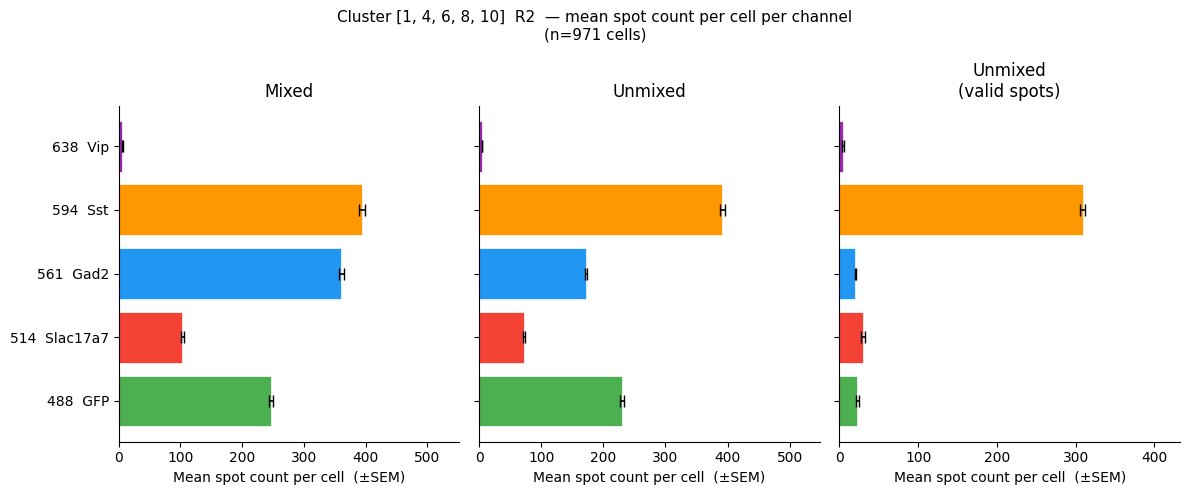

In [54]:
def plot_mean_spot_counts(
    m_spots,
    u_spots,
    cluster_list,
    rk,
    chan_order=CHAN_ORDER,
    chan_colors=CHAN_COLORS,
):
    """Horizontal bar charts of mean spot count per cell per channel (±SEM).
    Three panels: Mixed | Unmixed | Unmixed QC-filtered (valid_spot == True).
    Genes/channels on y-axis, bars extend horizontally."""
    u_valid = u_spots[u_spots["valid_spot"] == True] if "valid_spot" in u_spots.columns else u_spots

    datasets = [
        (m_spots, "Mixed"),
        (u_spots, "Unmixed"),
        (u_valid, "Unmixed\n(valid spots)"),
    ]

    n_chans = len(chan_order)
    fig, axes = plt.subplots(1, 3, figsize=(12, n_chans * 0.7 + 1.5), sharey=True)

    for ax, (spots, label) in zip(axes, datasets):
        spot_counts = (
            spots.groupby(["cell_id", "chan"])
            .size()
            .reset_index(name="n_spots")
        )
        mean_counts = spot_counts.groupby("chan")["n_spots"].mean()
        sem_counts  = spot_counts.groupby("chan")["n_spots"].sem()

        gene_col = "mixed_gene" if "mixed_gene" in spots.columns else spots.columns[-1]
        chan_to_gene = (
            spots.groupby("chan")[gene_col]
            .first()
            .reindex(chan_order)
        )

        chans = [c for c in chan_order if c in mean_counts.index]
        y = np.arange(len(chans))

        for i, chan in enumerate(chans):
            ax.barh(
                i, mean_counts[chan], xerr=sem_counts[chan],
                color=chan_colors.get(chan, "grey"),
                edgecolor="white", linewidth=0.5,
                capsize=4, error_kw={"elinewidth": 1.2},
            )

        ax.set_yticks(y)
        ax.set_yticklabels(
            [f"{c}  {chan_to_gene.get(c, '')}" for c in chans],
            fontsize=10,
        )
        ax.set_xlabel("Mean spot count per cell  (±SEM)")
        ax.set_title(label)
        ax.spines[["top", "right"]].set_visible(False)

        ax.set_xlim(0, mean_counts.max() * 1.4)

    n_cells = u_spots["cell_id"].nunique()
    fig.suptitle(
        f"Cluster {cluster_list}  {rk}  — mean spot count per cell per channel\n"
        f"(n={n_cells} cells)",
        fontsize=11,
    )
    fig.tight_layout()
    return fig


fig = plot_mean_spot_counts(m_cluster_spots, u_cluster_spots, cluster_list, rk)



# single

In [55]:
ADJACENT_PAIRS = [("488", "514"), ("514", "561"), ("561", "594"), ("594", "638")]

In [56]:
rk ="R2"
cid = 18878

/src/aind-hcr-data-loader/src/aind_hcr_data_loader/hcr_dataset.py:464: UserWarning: Getting cell info from cell x gene file. Does not include all segmentation masks; but this is usually fine.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/zarr/core/metadata/v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)



1-NN cross-channel distance summary  ((x×y×z, pixels)):
     Direction      n    median      mean       std       min       max
     488 → 514    210     8.337     8.722     3.449     1.414    17.578
     514 → 488     36     4.243     4.614     2.184     1.414    10.630
     514 → 561     36     4.301     4.149     1.592     1.414     7.483
     561 → 514    278     9.381     9.556     3.875     1.414    20.469
     561 → 594    278     3.162     3.259     1.327     1.414     7.681
     594 → 561    498     4.243     4.559     2.258     1.414    14.142
     594 → 638    498    29.068    30.400    15.839     1.414    61.847
     638 → 594      5     2.236     2.501     1.070     1.414     4.123

   Ch       n   med_ratio   med_z_int   med_score   % score>1
  488     210      11.589        0.17      12.601      100.0%
  514      36      10.481       -0.82      18.686      100.0%
  561     278       7.606        4.58       7.557       97.1%
  594     498       0.112        8.67       0.

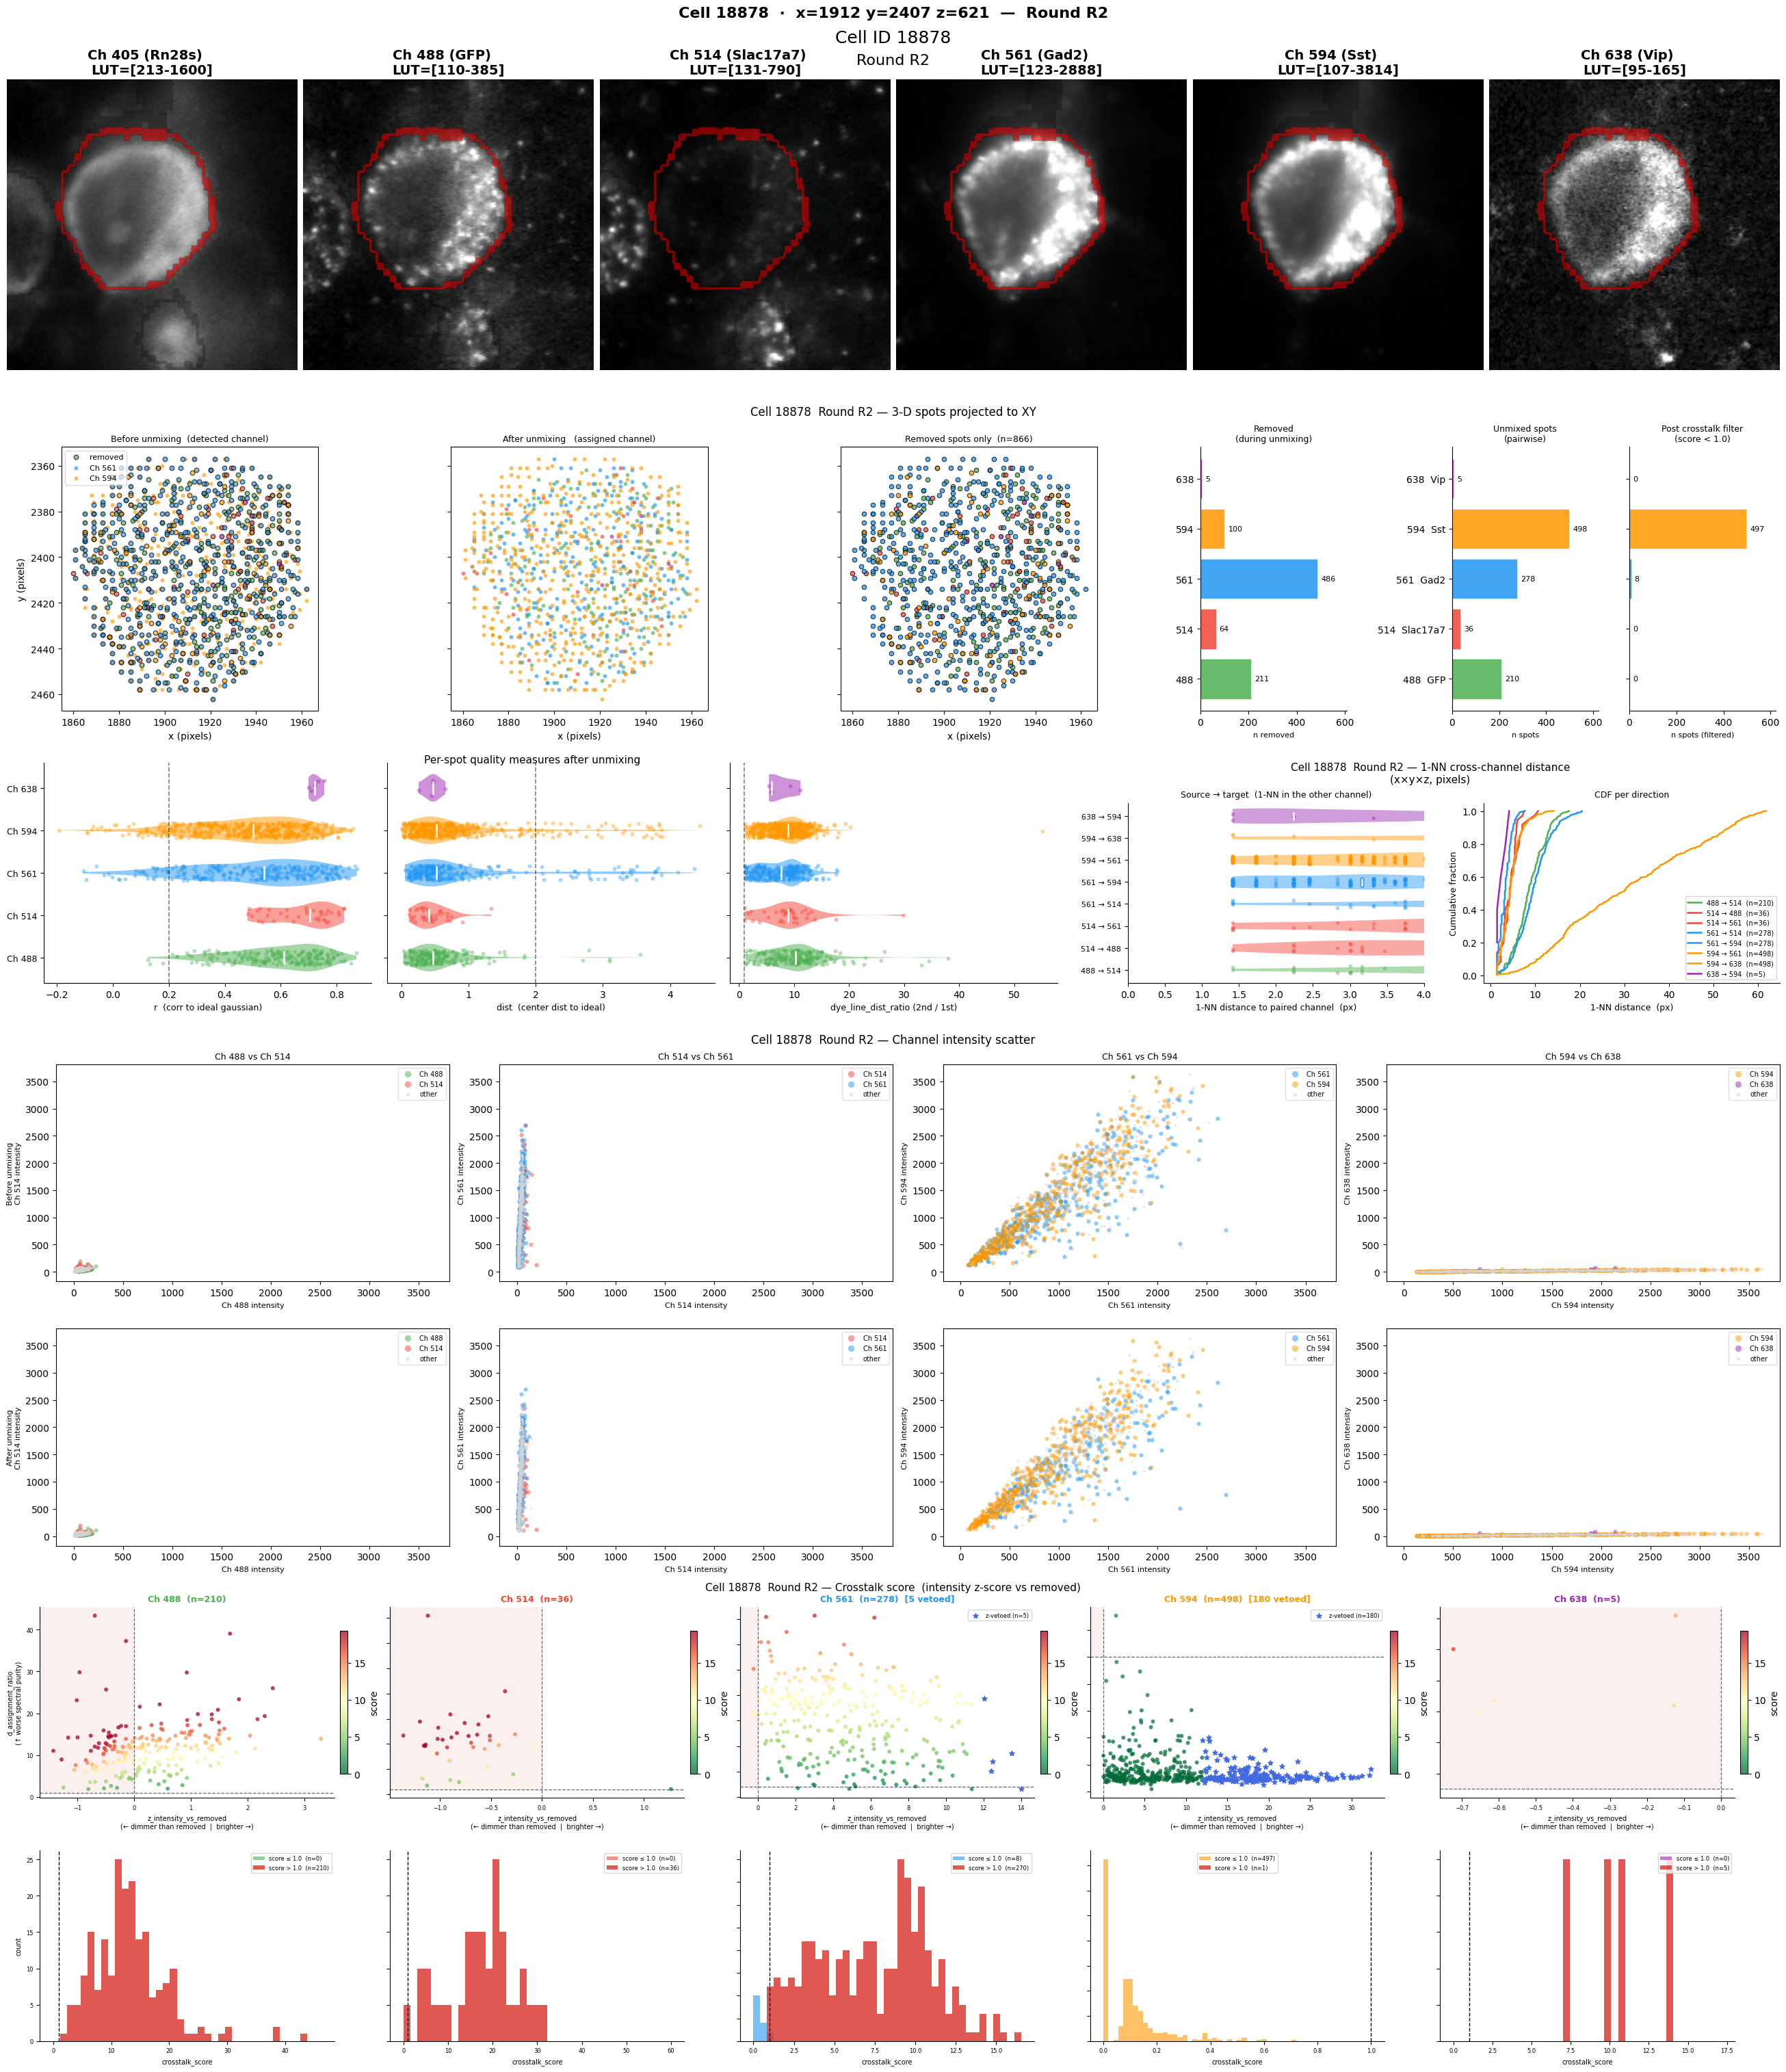

In [57]:
mx_rnd = mixed_ann[mixed_ann["round"] == rk]
um_rnd = unmixed_ann[unmixed_ann["round"] == rk]

m_cell = mx_rnd[mx_rnd["cell_id"] == cid]
u_cell = um_rnd[um_rnd["cell_id"] == cid]

save_kwargs = {"save": False,
                "output_dir": Path(f"/root/capsule/code/single_cell_unmixing_temp_plots/"),
                "filename":f"{MOUSE_ID}_{cid}",
                "show": True}
fig = plot_cell_qc(
    m_cell, u_cell, cell_id=cid, round_key=rk,
    chan_order=CHAN_ORDER, chan_colors=CHAN_COLORS,
    dataset=dataset,
    spots_df=u_cell,
    scatter_pairs=ADJACENT_PAIRS,
    **save_kwargs
)

# Feature explore

In [ ]:
# Available columns in unmixed spots:
# 'z', 'y', 'x', 'dist', 'r',
# 'chan_488_intensity', 'chan_514_intensity', 'chan_561_intensity', 'chan_594_intensity', 'chan_638_intensity',
# 'dye_line_dist_ratio', 'unmixed_chan', 'dist_r',
# 'dist_to_chan_488', 'dist_to_chan_514', 'dist_to_chan_561', 'dist_to_chan_594', 'dist_to_chan_638',
# 'd_assignment_ratio', 'z_intensity_vs_removed'


In [25]:
u_cluster_spots.columns

Index(['spot_id', 'spot_uid', 'spot_uid_int', 'chan', 'chan_spot_id',
       'cell_id', 'round', 'z', 'y', 'x', 'dist', 'r', 'chan_488_intensity',
       'chan_514_intensity', 'chan_561_intensity', 'chan_594_intensity',
       'chan_638_intensity', 'over_thresh', 'valid_spot',
       'dye_line_dist_ratio', 'unmixed_chan', 'dist_r', 'dist_to_chan_488',
       'dist_to_chan_514', 'dist_to_chan_561', 'dist_to_chan_594',
       'dist_to_chan_638', 'd_assignment_ratio', 'z_intensity_vs_removed',
       'z_vetoed', 'crosstalk_score', 'unmixed_gene', 'mixed_gene',
       'reassigned'],
      dtype='object')

In [35]:
# ── Feature exploration setup ─────────────────────────────────────────────────
# Reference populations (using full round, all cells, for richer statistics):
#   "good"    → chan 488, 561  (known real expression)
#   "suspect" → chan 514       (hypothesized dense-594 crosstalk)
#   "other"   → chan 594, 638

explore_df = u_cluster_spots.copy()

INTENSITY_COLS = [f"chan_{c}_intensity" for c in CHAN_ORDER]
DIST_TO_COLS   = [f"dist_to_chan_{c}" for c in CHAN_ORDER]

GOOD_CHANS    = ["488", "561"]
SUSPECT_CHANS = ["514"]

def _pop_label(chan):
    if chan in GOOD_CHANS:    return f"good ({chan})"
    if chan in SUSPECT_CHANS: return "suspect (514)"
    return f"other ({chan})"

explore_df["pop_label"] = explore_df["chan"].apply(_pop_label)

POP_ORDER  = ["good (488)", "good (561)", "suspect (514)", "other (594)", "other (638)"]
POP_COLORS = {
    "good (488)":    CHAN_COLORS.get("488", "steelblue"),
    "good (561)":    CHAN_COLORS.get("561", "limegreen"),
    "suspect (514)": CHAN_COLORS.get("514", "orange"),
    "other (594)":   CHAN_COLORS.get("594", "tomato"),
    "other (638)":   CHAN_COLORS.get("638", "mediumpurple"),
}
print(explore_df["pop_label"].value_counts())

# ── Phase 2: compute derived features ────────────────────────────────────────
chan_to_idx   = {c: i for i, c in enumerate(CHAN_ORDER)}
intensity_mat = explore_df[INTENSITY_COLS].values.astype(float)
assigned_idx  = explore_df["chan"].map(chan_to_idx).fillna(0).astype(int).values
assigned_int  = intensity_mat[np.arange(len(explore_df)), assigned_idx]
total_int     = intensity_mat.sum(axis=1)

# spectral purity: fraction of total intensity sitting in the assigned channel
explore_df["spectral_purity"]   = assigned_int / (total_int + 1e-9)
# off-peak fraction: complementary — how much leaks into non-assigned channels
explore_df["off_peak_fraction"] = 1.0 - explore_df["spectral_purity"]

# peak rank: 1 = assigned channel IS the brightest of the 5 (ideal for a real spot)
ranks = intensity_mat.shape[1] - np.argsort(np.argsort(intensity_mat, axis=1), axis=1)
explore_df["peak_rank"] = ranks[np.arange(len(explore_df)), assigned_idx].astype(float)

# contaminator ratio: how much brighter is the assigned channel vs 594
i594 = chan_to_idx["594"]
int_594 = intensity_mat[:, i594]
explore_df["assigned_vs_594"]    = assigned_int / (int_594 + 1e-9)
# bleed pressure: 594 brightness weighted by proximity — high → spot sits near dense 594
explore_df["bleed_pressure_594"] = int_594 / (explore_df["dist_to_chan_594"].values + 1.0)

DERIVED_FEATURES = [
    "spectral_purity", "off_peak_fraction", "peak_rank",
    "assigned_vs_594", "bleed_pressure_594",
]
print("\nMedian derived features by population:")
print(explore_df.groupby("pop_label")[DERIVED_FEATURES].median().round(3))


pop_label
other (594)      380140
good (488)       222790
good (561)       167120
suspect (514)     70181
other (638)        3966
Name: count, dtype: int64

Median derived features by population:
               spectral_purity  off_peak_fraction  peak_rank  assigned_vs_594  \
pop_label                                                                       
good (488)               0.125              0.875        3.0            0.274   
good (561)               0.413              0.587        2.0            0.945   
other (594)              0.497              0.503        1.0            1.000   
other (638)              0.076              0.924        4.0            0.190   
suspect (514)            0.187              0.813        3.0            0.557   

               bleed_pressure_594  
pop_label                          
good (488)                  4.107  
good (561)                  3.221  
other (594)                 6.086  
other (638)                 2.396  
suspect (514)       

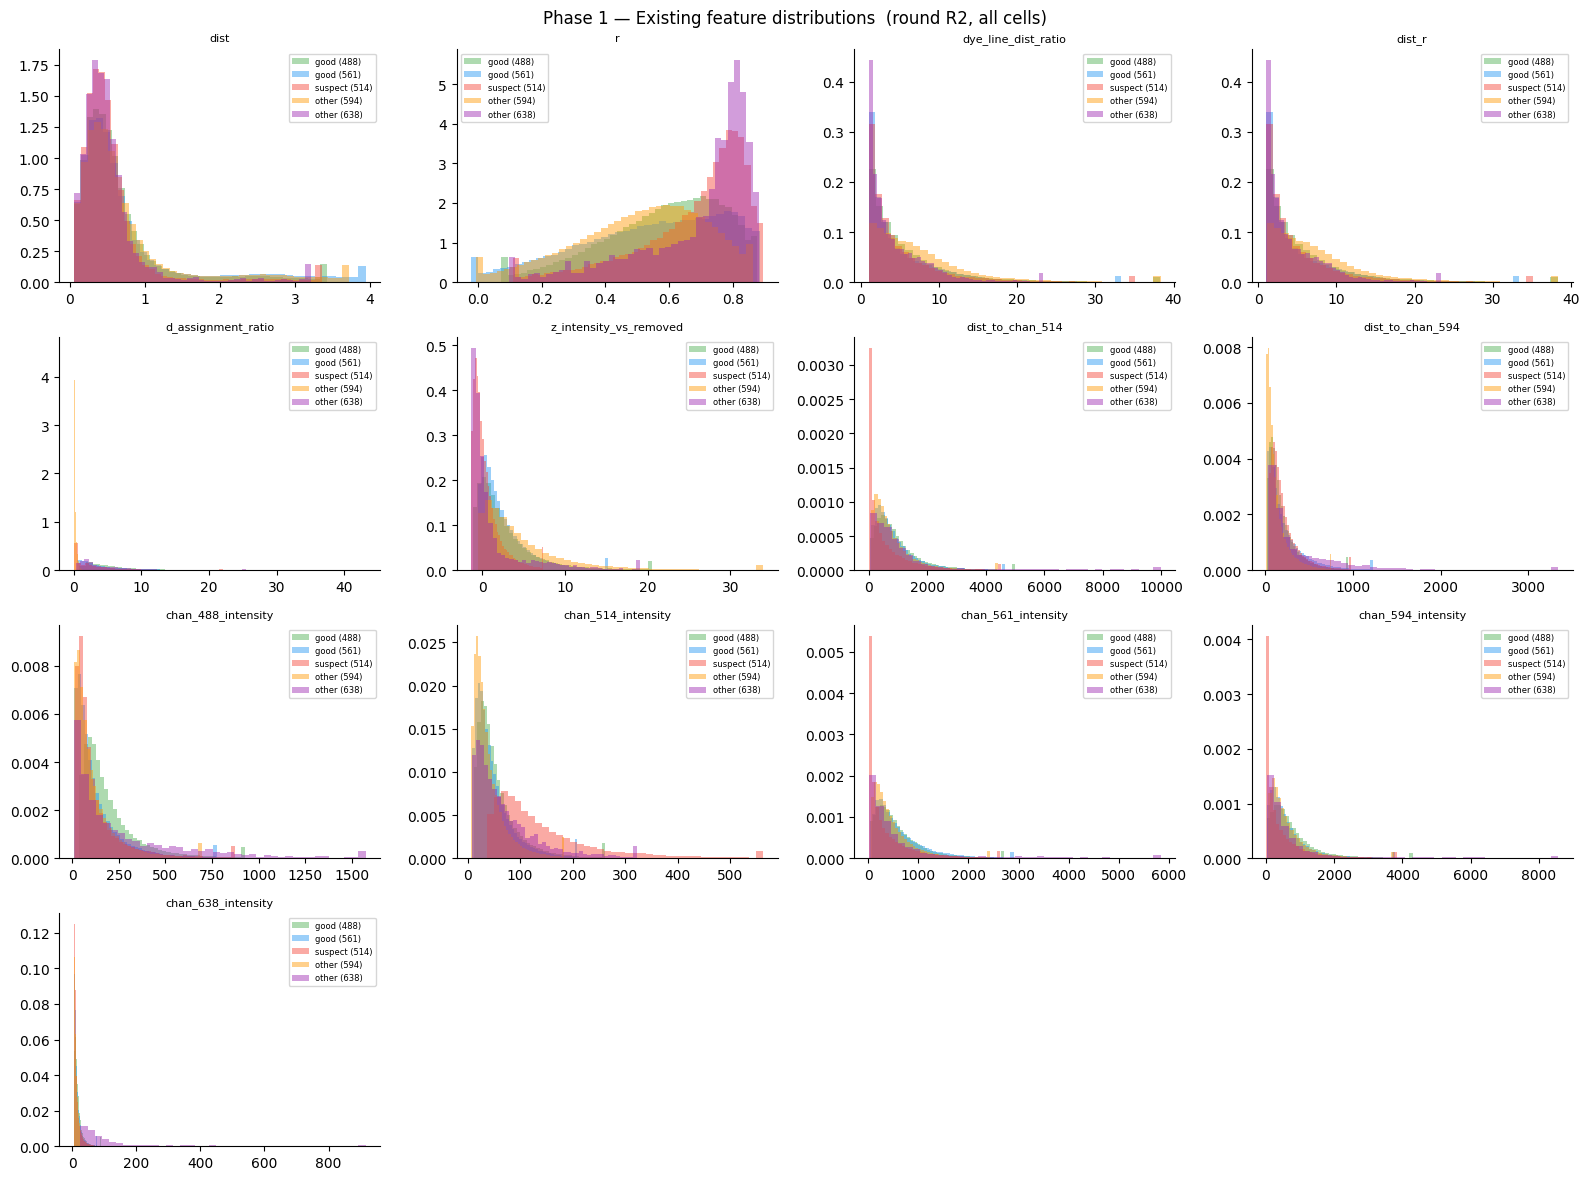

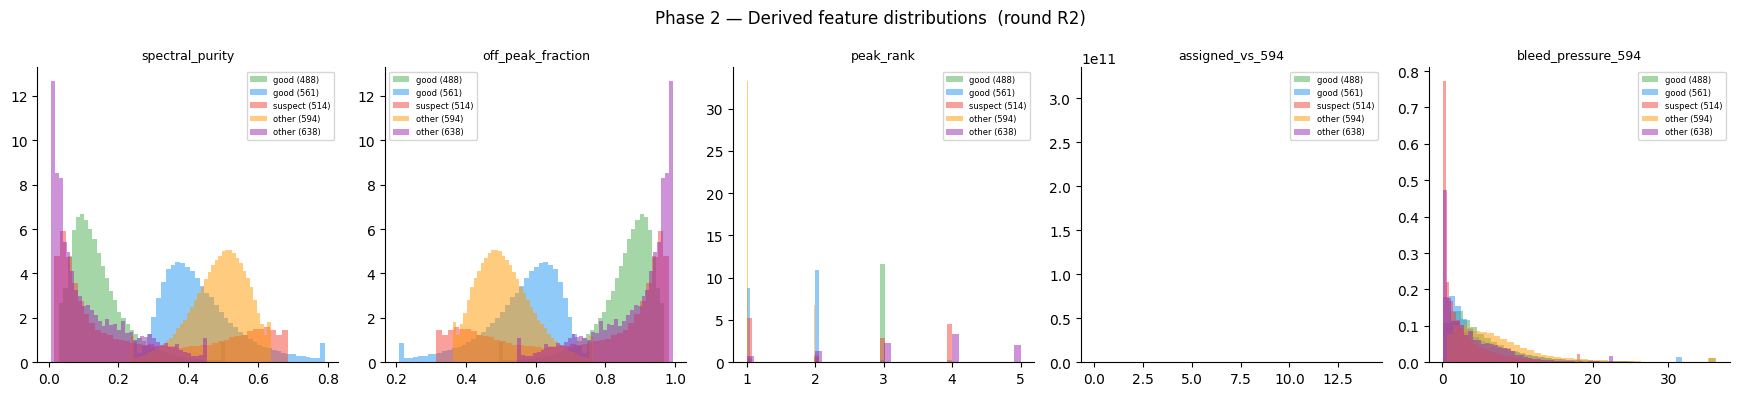

/tmp/ipykernel_47317/2205684502.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig3.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


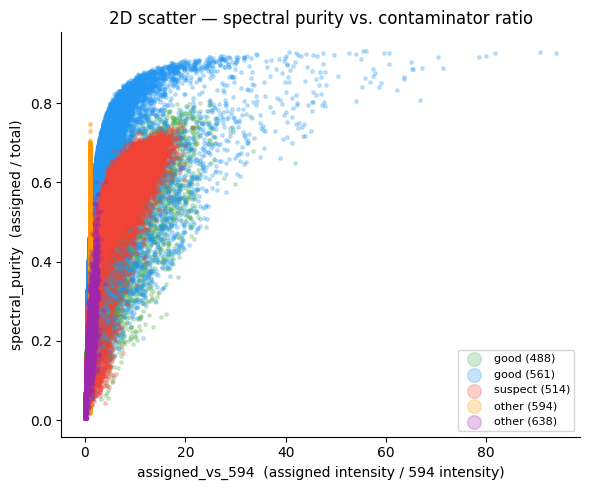

In [36]:
# ── Phase 1: Existing feature distributions split by channel population ───────
PHASE1_FEATURES = [
    "dist", "r", "dye_line_dist_ratio", "dist_r",
    "d_assignment_ratio", "z_intensity_vs_removed",
    "dist_to_chan_514", "dist_to_chan_594",
] + INTENSITY_COLS

ncols = 4
nrows = int(np.ceil(len(PHASE1_FEATURES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3))
axes = axes.flatten()

for ax, feat in zip(axes, PHASE1_FEATURES):
    for pop in POP_ORDER:
        sub = explore_df.loc[explore_df["pop_label"] == pop, feat].dropna()
        if len(sub) < 5:
            continue
        lo, hi = sub.quantile(0.01), sub.quantile(0.99)
        ax.hist(sub.clip(lo, hi), bins=40, density=True,
                alpha=0.45, color=POP_COLORS.get(pop, "grey"), label=pop)
    ax.set_title(feat, fontsize=8)
    ax.legend(fontsize=6)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[len(PHASE1_FEATURES):]:
    ax.set_visible(False)

fig.suptitle(f"Phase 1 — Existing feature distributions  (round {rk}, all cells)", fontsize=12)
fig.tight_layout()
plt.show()

# ── Phase 2: Derived feature distributions ────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(DERIVED_FEATURES), figsize=(len(DERIVED_FEATURES) * 3.5, 4))
for ax, feat in zip(axes2, DERIVED_FEATURES):
    for pop in POP_ORDER:
        sub = explore_df.loc[explore_df["pop_label"] == pop, feat].dropna()
        if len(sub) < 5:
            continue
        lo, hi = sub.quantile(0.01), sub.quantile(0.99)
        ax.hist(sub.clip(lo, hi), bins=40, density=True,
                alpha=0.5, color=POP_COLORS.get(pop, "grey"), label=pop)
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=6)
    ax.spines[["top", "right"]].set_visible(False)

fig2.suptitle(f"Phase 2 — Derived feature distributions  (round {rk})", fontsize=12)
fig2.tight_layout()
plt.show()

# ── Phase 2: 2D scatter — primary hypothesis ──────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(6, 5))
for pop in POP_ORDER:
    sub = explore_df[explore_df["pop_label"] == pop]
    ax3.scatter(
        sub["assigned_vs_594"], sub["spectral_purity"],
        s=6, alpha=0.25, label=pop, color=POP_COLORS.get(pop, "grey"),
    )
ax3.set_xlabel("assigned_vs_594  (assigned intensity / 594 intensity)")
ax3.set_ylabel("spectral_purity  (assigned / total)")
ax3.set_title("2D scatter — spectral purity vs. contaminator ratio")
ax3.legend(markerscale=4, fontsize=8)
ax3.spines[["top", "right"]].set_visible(False)
fig3.tight_layout()
plt.show()


In [34]:
explore_df

,spot_id,spot_uid,spot_uid_int,chan,chan_spot_id,cell_id,round,z,y,x,...,crosstalk_score,unmixed_gene,mixed_gene,reassigned,pop_label,spectral_purity,off_peak_fraction,peak_rank,assigned_vs_594,bleed_pressure_594
0,1,488_9,1,488,9,701,R2,281,1126,15,...,6.155782,GFP,GFP,False,good (488),0.370099,0.629901,2.0,6.255898,0.118108
1,2,488_10,2,488,10,701,R2,294,1166,46,...,12.157781,GFP,GFP,False,good (488),0.311960,0.688040,2.0,12.645845,0.044330
2,3,488_11,3,488,11,701,R2,294,1176,26,...,37.834656,GFP,GFP,False,good (488),0.353584,0.646416,2.0,14.768121,0.043350
3,4,488_12,4,488,12,701,R2,294,1177,20,...,5.310273,GFP,GFP,False,good (488),0.349330,0.650670,2.0,4.375045,0.168982
4,5,488_13,5,488,13,701,R2,297,1162,20,...,3.159054,GFP,GFP,False,good (488),0.315818,0.684182,2.0,2.638785,0.285860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12279241,16394470,638_338541,16394470,638,338541,83103,R2,1151,4449,5513,...,0.711635,Vip,Vip,False,other (638),0.370897,0.629103,1.0,2.340937,0.327992
12279242,16394471,638_338542,16394471,638,338542,83103,R2,1151,4452,5507,...,5.750531,Vip,Vip,False,other (638),0.287517,0.712483,2.0,2.107859,0.264241
12279243,16394472,638_338543,16394472,638,338543,83103,R2,1155,4483,5506,...,4.919385,Vip,Vip,False,other (638),0.285393,0.714607,2.0,2.139256,0.255647
12279244,16394473,638_338544,16394473,638,338544,83103,R2,1158,4481,5509,...,3.141861,Vip,Vip,False,other (638),0.312417,0.687583,2.0,2.160802,0.285602


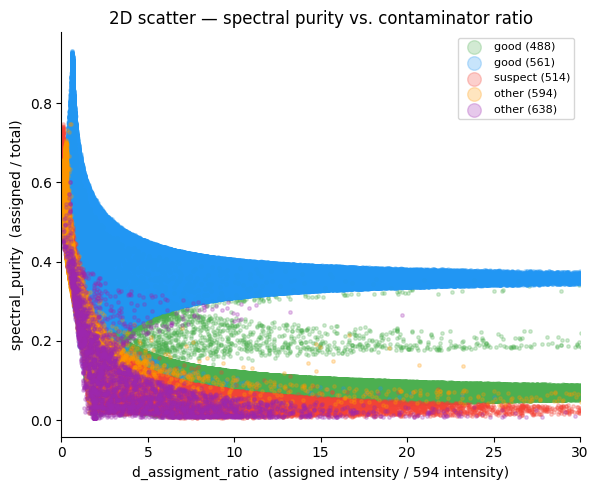

In [38]:
# ── Phase 2: 2D scatter — primary hypothesis ──────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(6, 5))
for pop in POP_ORDER:
    sub = explore_df[explore_df["pop_label"] == pop]
    ax3.scatter(
        sub["d_assignment_ratio"], sub["spectral_purity"],
        s=6, alpha=0.25, label=pop, color=POP_COLORS.get(pop, "grey"),
    )
ax3.set_xlabel("d_assigment_ratio  (assigned intensity / 594 intensity)")
ax3.set_ylabel("spectral_purity  (assigned / total)")
ax3.set_title("2D scatter — spectral purity vs. contaminator ratio")
ax3.legend(markerscale=4, fontsize=8, loc="upper right")
ax3.spines[["top", "right"]].set_visible(False)
fig3.tight_layout()
ax3.set_xlim(0, 30)
plt.show()



# Phase 3 — Separability analysis

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

# ── Build binary label: 1 = suspect (514), 0 = good (488 or 561) ─────────────
phase3_df = explore_df[explore_df["chan"].isin(["488", "514", "561"])].copy()
phase3_df["is_suspect"] = (phase3_df["chan"] == "514").astype(int)

ALL_FEATURES = [
    # existing
    "dist", "r", "dye_line_dist_ratio", "dist_r",
    "d_assignment_ratio", "z_intensity_vs_removed",
    #"dist_to_chan_514", "dist_to_chan_594",
]  + DERIVED_FEATURES # INTENSITY_COLS

feat_df = phase3_df[ALL_FEATURES].copy()
feat_df = feat_df.replace([np.inf, -np.inf], np.nan).fillna(feat_df.median())

X = feat_df.values
y = phase3_df["is_suspect"].values

# ── 3a: Point-biserial correlation of each feature with is_suspect ────────────
from scipy.stats import pointbiserialr

corrs = {}
for feat in ALL_FEATURES:
    r, p = pointbiserialr(y, feat_df[feat].values)
    corrs[feat] = (r, p)

corr_df = (
    pd.DataFrame(corrs, index=["r", "p"]).T
    .sort_values("r", key=abs, ascending=False)
)
print("Feature correlations with is_suspect (514 vs 488+561):")
print(corr_df.round(3).to_string())


Feature correlations with is_suspect (514 vs 488+561):
                            r      p
assigned_vs_594         0.241  0.000
z_intensity_vs_removed -0.221  0.000
r                       0.194  0.000
bleed_pressure_594     -0.166  0.000
d_assignment_ratio     -0.150  0.000
dist                   -0.083  0.000
peak_rank               0.075  0.000
dye_line_dist_ratio    -0.025  0.000
dist_r                 -0.025  0.000
spectral_purity         0.003  0.067
off_peak_fraction      -0.003  0.067


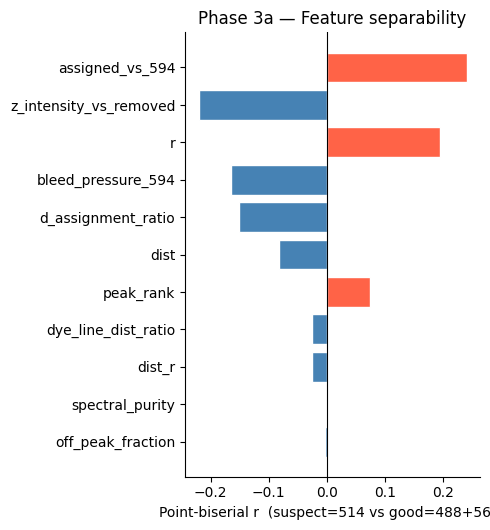


Decision tree feature importances (depth=5):
d_assignment_ratio        0.404
peak_rank                 0.282
z_intensity_vs_removed    0.148
off_peak_fraction         0.065
bleed_pressure_594        0.056
r                         0.027
dye_line_dist_ratio       0.017
assigned_vs_594           0.002
spectral_purity           0.000
dist_r                    0.000
dist                      0.000


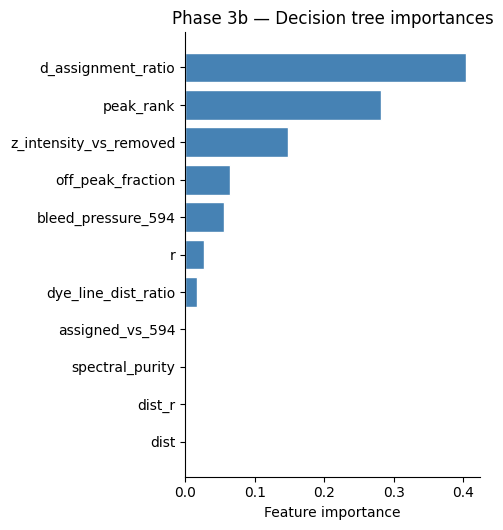


Logistic regression coefficients:
d_assignment_ratio       -5.886
dist_r                    4.512
dye_line_dist_ratio       4.512
bleed_pressure_594       -3.726
z_intensity_vs_removed   -1.897
peak_rank                 0.682
r                         0.551
off_peak_fraction         0.343
spectral_purity          -0.343
assigned_vs_594           0.194
dist                     -0.114

Classification report (train set):
              precision    recall  f1-score   support

        good       0.97      0.82      0.89    389910
     suspect       0.46      0.85      0.60     70181

    accuracy                           0.82    460091
   macro avg       0.71      0.83      0.74    460091
weighted avg       0.89      0.82      0.84    460091



In [47]:
# ── 3b: Correlation bar chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, len(ALL_FEATURES) * 0.4 + 1))
colors = ["tomato" if r > 0 else "steelblue" for r in corr_df["r"]]
ax.barh(corr_df.index[::-1], corr_df["r"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Point-biserial r  (suspect=514 vs good=488+561)")
ax.set_title("Phase 3a — Feature separability")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# ── 3c: Decision tree feature importances ────────────────────────────────────
scaler = StandardScaler()
X_sc   = scaler.fit_transform(X)

dt = DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42)
dt.fit(X_sc, y)
imp_df = (
    pd.Series(dt.feature_importances_, index=ALL_FEATURES)
    .sort_values(ascending=False)
)
print("\nDecision tree feature importances (depth=5):")
print(imp_df.round(3).to_string())

fig2, ax2 = plt.subplots(figsize=(5, len(ALL_FEATURES) * 0.4 + 1))
ax2.barh(imp_df.index[::-1], imp_df.values[::-1], color="steelblue", edgecolor="white")
ax2.set_xlabel("Feature importance")
ax2.set_title("Phase 3b — Decision tree importances")
ax2.spines[["top", "right"]].set_visible(False)
fig2.tight_layout()
plt.show()

# ── 3d: Logistic regression coefficients (L2) ─────────────────────────────────
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr.fit(X_sc, y)
coef_df = (
    pd.Series(lr.coef_[0], index=ALL_FEATURES)
    .sort_values(key=abs, ascending=False)
)
print("\nLogistic regression coefficients:")
print(coef_df.round(3).to_string())
print("\nClassification report (train set):")
print(classification_report(y, lr.predict(X_sc), target_names=["good", "suspect"]))


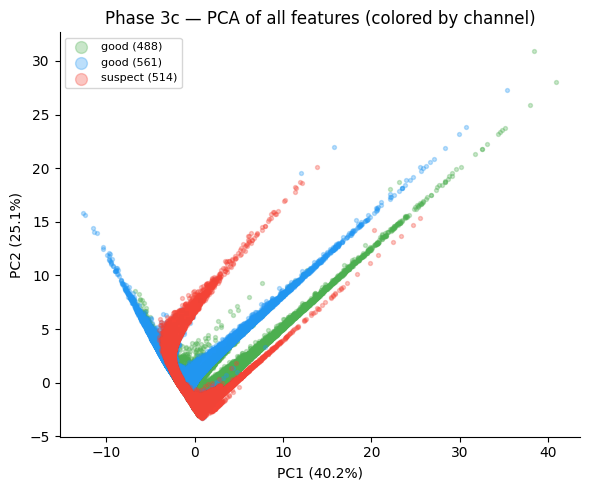


Top PC1 loadings:
d_assignment_ratio     0.427
bleed_pressure_594     0.419
dist_r                 0.376
dye_line_dist_ratio    0.376
spectral_purity       -0.329
off_peak_fraction      0.329
peak_rank              0.299
assigned_vs_594       -0.220


In [48]:
# ── 3e: PCA of feature space colored by channel population ───────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sc)

fig, ax = plt.subplots(figsize=(6, 5))
for pop in POP_ORDER:
    mask = phase3_df["pop_label"] == pop
    if mask.sum() == 0:
        continue
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=8, alpha=0.3, label=pop, color=POP_COLORS.get(pop, "grey"))
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Phase 3c — PCA of all features (colored by channel)")
ax.legend(markerscale=3, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print(f"\nTop PC1 loadings:")
pc1_load = pd.Series(pca.components_[0], index=ALL_FEATURES).sort_values(key=abs, ascending=False)
print(pc1_load.round(3).head(8).to_string())


# Phase 4 — Threshold exploration

/tmp/ipykernel_47317/4025999961.py:34: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


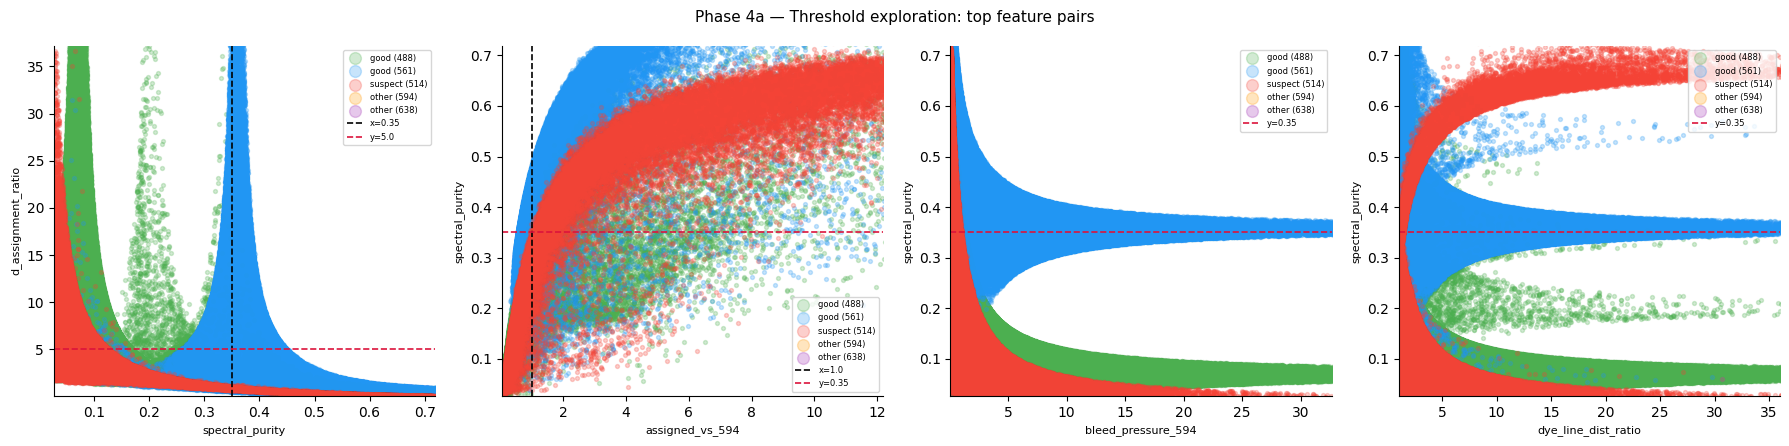

In [49]:
# ── Phase 4a: Top-2 feature scatter pairs with candidate thresholds ───────────
# Use the top features from Phase 3 (by DT importance + correlation) to draw
# exploratory cut lines. Adjust thresholds below after inspecting.

TOP_PAIRS = [
    ("spectral_purity",   "d_assignment_ratio",  0.35, 5.0),   # (feat_x, feat_y, thresh_x, thresh_y)
    ("assigned_vs_594",   "spectral_purity",      1.0,  0.35),
    ("bleed_pressure_594","spectral_purity",      None, 0.35),
    ("dye_line_dist_ratio","spectral_purity",     None, 0.35),
]

nplots = len(TOP_PAIRS)
fig, axes = plt.subplots(1, nplots, figsize=(nplots * 4.5, 4.5))

for ax, (fx, fy, tx, ty) in zip(axes, TOP_PAIRS):
    for pop in POP_ORDER:
        sub = phase3_df[phase3_df["pop_label"] == pop]
        ax.scatter(sub[fx], sub[fy], s=8, alpha=0.25,
                   color=POP_COLORS.get(pop, "grey"), label=pop)
    if tx is not None:
        ax.axvline(tx, color="black", linewidth=1.2, linestyle="--", label=f"x={tx}")
    if ty is not None:
        ax.axhline(ty, color="crimson", linewidth=1.2, linestyle="--", label=f"y={ty}")
    ax.set_xlabel(fx, fontsize=8)
    ax.set_ylabel(fy, fontsize=8)
    # clip axes to 1–99 percentile for readability
    for feat, axis_fn in [(fx, ax.set_xlim), (fy, ax.set_ylim)]:
        lo, hi = phase3_df[feat].quantile(0.01), phase3_df[feat].quantile(0.99)
        axis_fn(lo, hi)
    ax.legend(fontsize=6, markerscale=3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Phase 4a — Threshold exploration: top feature pairs", fontsize=11)
fig.tight_layout()
plt.show()


ROC-AUC (spectral_purity as discriminator): 0.537


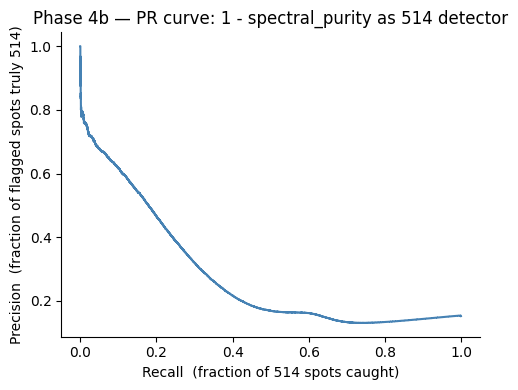


% spots retained by spectral_purity threshold:

chan                     488   514   561
spectral_purity_thresh                  
0.15                    36.8  54.7  99.8
0.20                    19.6  48.6  99.5
0.25                    10.8  43.9  98.7
0.30                     6.1  39.8  94.3
0.35                     3.6  36.2  77.6
0.40                     2.3  32.7  55.4
0.45                     1.5  29.0  36.5
0.50                     1.0  24.6  22.9


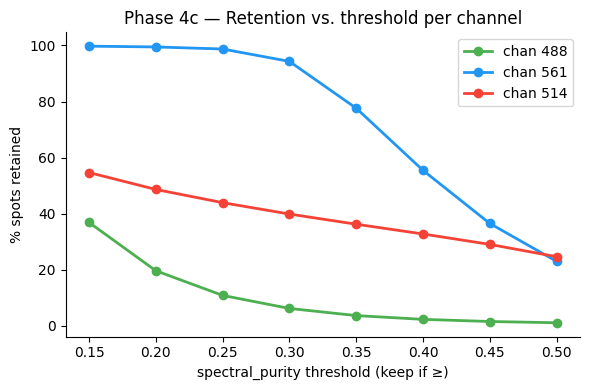

In [50]:
# ── Phase 4b: Precision-recall sweep over spectral_purity threshold ───────────
# Treat 514 as "positive" (to remove). Sweep threshold on spectral_purity.
# A good threshold keeps most 488/561 spots while cutting 514.

from sklearn.metrics import precision_recall_curve, roc_auc_score

# Use spectral_purity as a score: LOW purity → suspect
score = 1.0 - phase3_df["spectral_purity"].values  # high score = more suspect

prec, rec, thresholds_pr = precision_recall_curve(y, score)
try:
    auc = roc_auc_score(y, score)
    print(f"ROC-AUC (spectral_purity as discriminator): {auc:.3f}")
except Exception:
    pass

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rec, prec, color="steelblue")
ax.set_xlabel("Recall  (fraction of 514 spots caught)")
ax.set_ylabel("Precision  (fraction of flagged spots truly 514)")
ax.set_title("Phase 4b — PR curve: 1 - spectral_purity as 514 detector")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# ── Phase 4c: Retention table — how many good spots survive each cut? ─────────
thresholds_to_test = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
rows = []
for t in thresholds_to_test:
    for chan in ["488", "514", "561"]:
        sub = phase3_df[phase3_df["chan"] == chan]
        n_total = len(sub)
        n_pass  = (sub["spectral_purity"] >= t).sum()
        rows.append({"spectral_purity_thresh": t, "chan": chan,
                     "n_total": n_total, "n_pass": n_pass,
                     "pct_pass": 100 * n_pass / n_total if n_total else 0})

ret_df = pd.DataFrame(rows)
pivot  = ret_df.pivot(index="spectral_purity_thresh", columns="chan", values="pct_pass").round(1)
print("\n% spots retained by spectral_purity threshold:\n")
print(pivot.to_string())

fig2, ax2 = plt.subplots(figsize=(6, 4))
for chan in ["488", "561", "514"]:
    sub = ret_df[ret_df["chan"] == chan]
    ax2.plot(sub["spectral_purity_thresh"], sub["pct_pass"],
             marker="o", color=CHAN_COLORS.get(chan, "grey"),
             label=f"chan {chan}", linewidth=2)
ax2.set_xlabel("spectral_purity threshold (keep if ≥)")
ax2.set_ylabel("% spots retained")
ax2.set_title("Phase 4c — Retention vs. threshold per channel")
ax2.legend()
ax2.spines[["top", "right"]].set_visible(False)
fig2.tight_layout()
plt.show()


# Simplified model — top independent features

Pearson r(dist_r, dye_line_dist_ratio): 1.0

Simple LR coefficients:
  bleed_pressure_594             -7.350
  dye_line_dist_ratio            +4.121
  d_assignment_ratio             +2.817
  z_intensity_vs_removed         -2.339

Classification report (simple model, train set):
              precision    recall  f1-score   support

        good       0.96      0.76      0.85    389910
     suspect       0.39      0.84      0.53     70181

    accuracy                           0.78    460091
   macro avg       0.68      0.80      0.69    460091
weighted avg       0.88      0.78      0.80    460091

Decision tree rules (depth=3, original feature units):
|--- d_assignment_ratio <= 0.60
|   |--- bleed_pressure_594 <= 0.05
|   |   |--- dye_line_dist_ratio <= 7.81
|   |   |   |--- class: 0
|   |   |--- dye_line_dist_ratio >  7.81
|   |   |   |--- class: 1
|   |--- bleed_pressure_594 >  0.05
|   |   |--- dye_line_dist_ratio <= 2.08
|   |   |   |--- class: 1
|   |   |--- dye_line_dist_ratio >

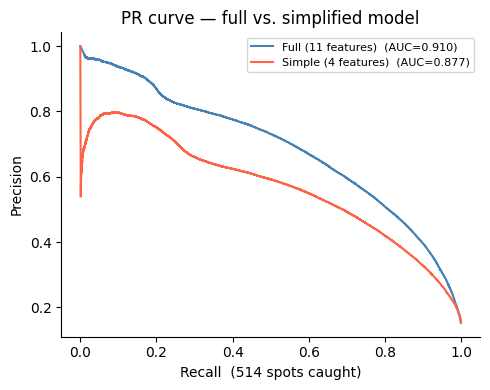

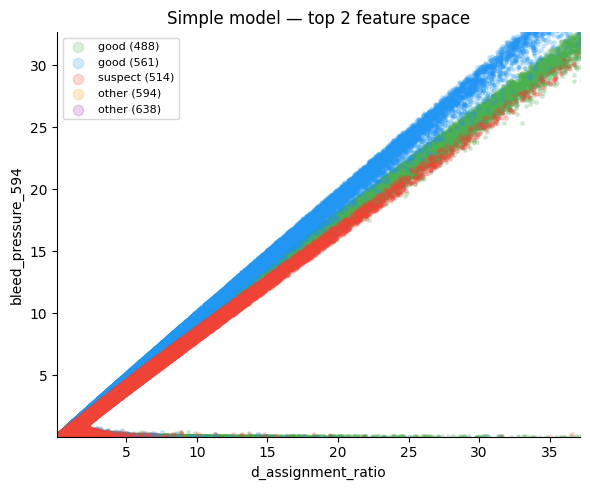

In [65]:
# Note: dist_r and dye_line_dist_ratio had identical LR coefficients (4.512) → collinear.
# Drop one. Check correlation to confirm.
print("Pearson r(dist_r, dye_line_dist_ratio):",
      phase3_df[["dist_r", "dye_line_dist_ratio"]].corr().iloc[0, 1].round(4))

# ── Top 4 independent features ────────────────────────────────────────────────
SIMPLE_FEATURES = [
    "d_assignment_ratio",    # strongest single predictor
    "dye_line_dist_ratio",   # keep one of the collinear pair
    "bleed_pressure_594",    # physical contamination pressure
    "z_intensity_vs_removed",# spot quality signal
]

Xs_df = phase3_df[SIMPLE_FEATURES].copy()
Xs_df = Xs_df.replace([np.inf, -np.inf], np.nan).fillna(Xs_df.median())
Xs    = StandardScaler().fit_transform(Xs_df.values)

# ── Logistic regression ───────────────────────────────────────────────────────
lr_simple = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_simple.fit(Xs, y)

print("\nSimple LR coefficients:")
for feat, coef in sorted(zip(SIMPLE_FEATURES, lr_simple.coef_[0]), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feat:<30} {coef:+.3f}")

print("\nClassification report (simple model, train set):")
print(classification_report(y, lr_simple.predict(Xs), target_names=["good", "suspect"]))

# ── Decision tree (depth 3) — interpretable rule extraction ──────────────────
from sklearn.tree import export_text

dt_simple = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
dt_simple.fit(Xs_df.values, y)  # unscaled so thresholds are in original units

print("Decision tree rules (depth=3, original feature units):")
print(export_text(dt_simple, feature_names=SIMPLE_FEATURES))
print("Decision tree importances:")
for feat, imp in sorted(zip(SIMPLE_FEATURES, dt_simple.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f"  {feat:<30} {imp:.3f}")

# ── PR curve comparison: full vs simple model ─────────────────────────────────
from sklearn.metrics import precision_recall_curve, roc_auc_score

score_full   = lr.predict_proba(X_sc)[:, 1]
score_simple = lr_simple.predict_proba(Xs)[:, 1]

fig, ax = plt.subplots(figsize=(5, 4))
for score, label, color in [
    (score_full,   f"Full ({len(ALL_FEATURES)} features)",   "steelblue"),
    (score_simple, f"Simple ({len(SIMPLE_FEATURES)} features)", "tomato"),
]:
    p, r, _ = precision_recall_curve(y, score)
    auc_val  = roc_auc_score(y, score)
    ax.plot(r, p, color=color, label=f"{label}  (AUC={auc_val:.3f})")

ax.set_xlabel("Recall  (514 spots caught)")
ax.set_ylabel("Precision")
ax.set_title("PR curve — full vs. simplified model")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

# ── 2D decision boundary: top 2 features ─────────────────────────────────────
fx, fy = "d_assignment_ratio", "bleed_pressure_594"
fig2, ax2 = plt.subplots(figsize=(6, 5))
for pop in POP_ORDER:
    sub = phase3_df[phase3_df["pop_label"] == pop]
    ax2.scatter(sub[fx], sub[fy], s=6, alpha=0.2,
                color=POP_COLORS.get(pop, "grey"), label=pop)
# threshold from DT at depth-1 split (most interpretable)
ax2.set_xlabel(fx); ax2.set_ylabel(fy)
ax2.set_xlim(*[phase3_df[fx].quantile(q) for q in [0.01, 0.99]])
ax2.set_ylim(*[phase3_df[fy].quantile(q) for q in [0.01, 0.99]])
ax2.set_title("Simple model — top 2 feature space")
ax2.legend(markerscale=3, fontsize=8)
ax2.spines[["top", "right"]].set_visible(False)
fig2.tight_layout()
plt.show()
